In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import pickle
import open3d
import json

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [2]:
with open("parameters.pickle", "rb") as file:
    M1, d1, M2, d2, T, R, Q, ROI1, ROI2, R1, R2, Pn1, Pn2 = pickle.load(file)

mapl1, mapl2 = cv2.initUndistortRectifyMap(M1, d1, R1, Pn1, (800,600), cv2.CV_16SC2 )
mapr1, mapr2 = cv2.initUndistortRectifyMap(M2, d2, R2, Pn2, (800,600), cv2.CV_16SC2 )

In [3]:
MIN_DIST = 0.200
MAX_DIST = 3.000
baseline = 1/Q[3,2]
f = Q[2,3]
max_disp = (f * baseline) / MIN_DIST
min_disp = (f*baseline) / MAX_DIST

In [4]:
print(max_disp)
print(min_disp)

193.9893990377341
12.932626602515606


In [5]:
num_disparities = max_disp - min_disp
num_disparities = int(np.ceil(num_disparities / 16) * 16)
min_disp = int(min_disp)

In [6]:
def census(image: cv2.Mat):
    h = image.shape[0]
    w = image.shape[1]
    out = np.zeros((h-2,w-2), dtype=np.uint8)

    cp = image[1:h-1, 1:w-1]
    offsets = [(u, v) for v in range(3) for u in range(3) if not u == 1 == v]
    for u,v in offsets:
        out = (out << 1) | (image[v:v+h-2, u:u+w-2] >= cp)
    return out

In [7]:
def plot_image_pair(number: int):
    left = cv2.remap(
        cv2.imread(f"left-{number}.png", cv2.IMREAD_GRAYSCALE),
        mapl1, mapl2,
        cv2.INTER_LANCZOS4
        )
    right = cv2.remap(
        cv2.imread(f"right-{number}.png", cv2.IMREAD_GRAYSCALE),
        mapr1, mapr2,
        cv2.INTER_LANCZOS4
        )
    
    bml = cv2.StereoSGBM.create(
        numDisparities=num_disparities, 
        minDisparity=min_disp,
        blockSize=3, 
        mode=cv2.STEREO_SGBM_MODE_HH,
        disp12MaxDiff=1,
        uniquenessRatio=15,
        speckleWindowSize=150,
        speckleRange=5,
        P1=8*3*3,
        P2=32*3*3
    )

    bmr = cv2.ximgproc.createRightMatcher(bml)
    filter = cv2.ximgproc.createDisparityWLSFilter(bml)
    filter.setLambda(8000)
    filter.setSigmaColor(0.6)
    displ = bml.compute(left, right)
    disp = filter.filter(displ, left, None, bmr.compute(right, left))
    depth = cv2.reprojectImageTo3D(disp.astype(np.float32)/16, Q)[:,:,2]

    fig = plt.figure(figsize=[10, 10])
    ax = fig.subplots(2, 3)
    
    ax[0,0].imshow(left, cmap="gray")
    ax[0,0].set_title("Left Image")

    ax[0,1].imshow(right, cmap="gray")
    ax[0,1].set_title("Right Image")

    ax[0,2].imshow((displ-bml.getMinDisparity())/bml.getNumDisparities(), cmap="gray")
    ax[0,2].set_title("Disparity")

    disp[disp < 0] = 0
    ax[1,0].imshow(disp/np.max(disp), cmap="gray")
    ax[1,0].set_title("Filtered Disparity")

    conf = filter.getConfidenceMap()
    ax[1,1].imshow(conf/np.max(conf), cmap="gray")
    ax[1,1].set_title("Filter Confidence")
    
    depth[depth < 0] = 0
    depth[depth > 50] = 50
    depth[np.isinf(depth)] = 50
    ax[1,2].imshow(depth/np.max(depth), cmap="gray")
    ax[1,2].set_title("Depth Map")
    

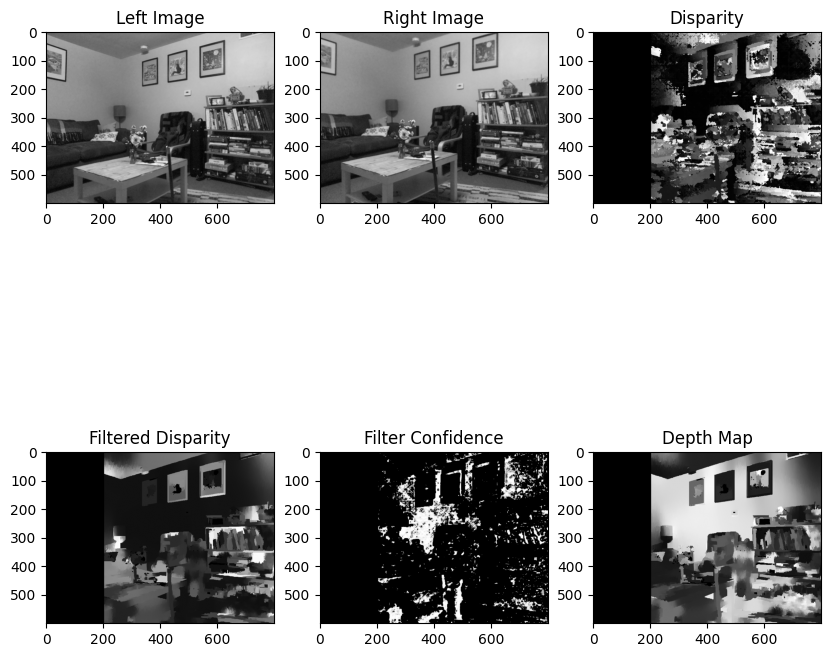

In [8]:
plot_image_pair(0)

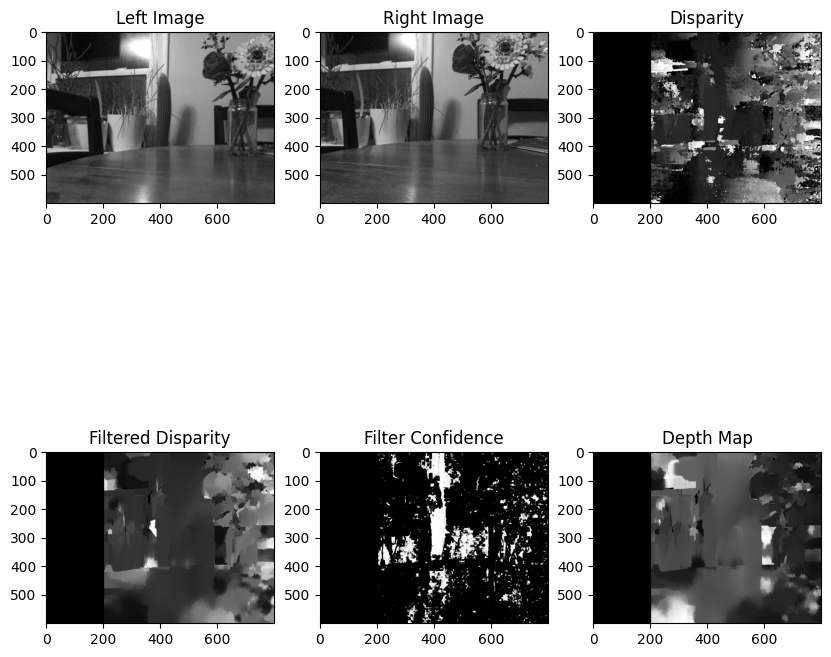

In [9]:
plot_image_pair(1)

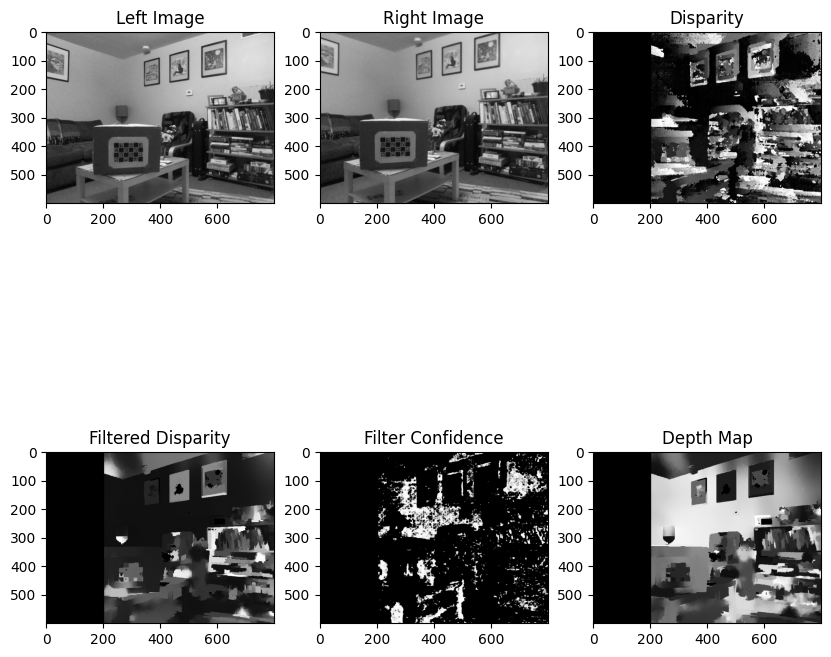

In [10]:
plot_image_pair(2)

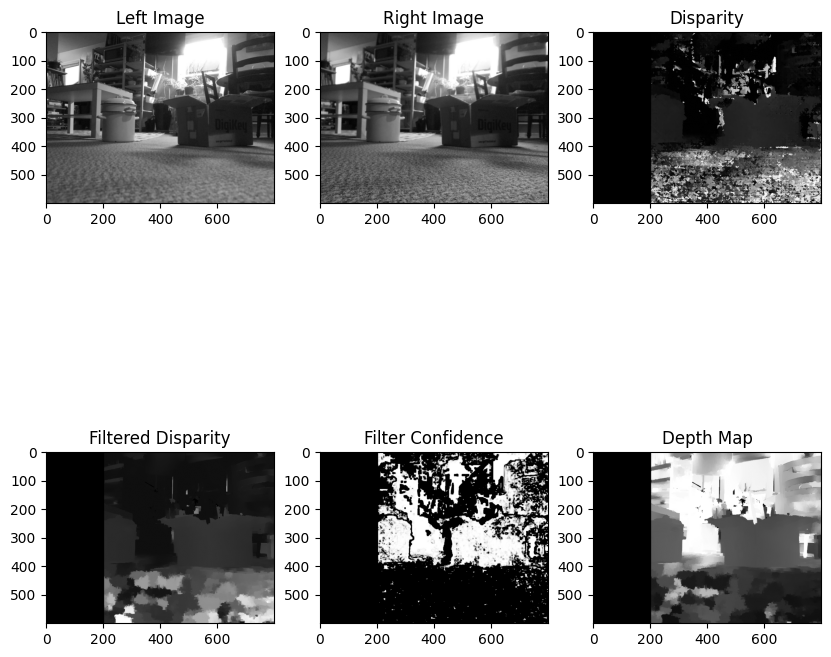

In [11]:
plot_image_pair(3)

In [12]:
left = cv2.remap(
    cv2.imread(f"left-3.png", cv2.IMREAD_GRAYSCALE),
    mapl1, mapl2,
    cv2.INTER_LANCZOS4
    )
right = cv2.remap(
    cv2.imread(f"right-3.png", cv2.IMREAD_GRAYSCALE),
    mapr1, mapr2,
    cv2.INTER_LANCZOS4
    )

bml = cv2.StereoSGBM.create(
    minDisparity=min_disp,
    numDisparities=num_disparities, 
    blockSize=3, 
    mode=cv2.STEREO_SGBM_MODE_HH,
    disp12MaxDiff=1,
    uniquenessRatio=15,
    speckleWindowSize=150,
    speckleRange=5,
    P1=8*3*3,
    P2=32*3*3
)

bmr = cv2.ximgproc.createRightMatcher(bml)
filter = cv2.ximgproc.createDisparityWLSFilter(bml)
filter.setLambda(8000)
filter.setSigmaColor(0.6)
displ = bml.compute(left, right)
disp = filter.filter(displ, left, None, bmr.compute(right, left))

pts = cv2.reprojectImageTo3D(displ.astype(np.float32)/16, Q)
pts_filter = cv2.reprojectImageTo3D(disp.astype(np.float32)/16, Q)

In [13]:
points = pts.reshape(-1,3)
colors = np.array([np.array([1.0, 1.0, 1.0])*x/255 for x in left.reshape(-1,1)])
mask = (points[:,2] > 0) & (points[:,2] < 5)

ptc = open3d.geometry.PointCloud()
ptc.points = open3d.utility.Vector3dVector(points[mask])
ptc.colors = open3d.utility.Vector3dVector(colors[mask])
cl, ind = ptc.remove_radius_outlier(nb_points=25, radius=0.1)
open3d.visualization.draw_geometries([ptc.select_by_index(ind)])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 


In [14]:
points = pts_filter.reshape(-1,3)
colors = np.array([np.array([1.0, 1.0, 1.0])*x/255 for x in left.reshape(-1,1)])
mask = (points[:,2] > 0) & (points[:,2] < 5) & (filter.getConfidenceMap().reshape(-1,1)[:,0] > 100)

ptc = open3d.geometry.PointCloud()
ptc.points = open3d.utility.Vector3dVector(points[mask])
ptc.colors = open3d.utility.Vector3dVector(colors[mask])
open3d.visualization.draw_geometries([ptc])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make conte

In [17]:
cl, ind = ptc.remove_radius_outlier(nb_points=50, radius=0.05)
open3d.visualization.draw_geometries([ptc.select_by_index(ind)])

[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The handle is invalid. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make context current: The requested transformation operation is not supported. 
[Open3D WARNING] GLFW Error: WGL: Failed to make conte